In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as T
from sklearn.metrics import roc_curve, auc, confusion_matrix
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [2]:
train_dir = "C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 1/dataset 1/dataset/train"
val_dir = "C:/Users/upraj/Prajwal/GSOC/Unsupervised_SR/Task 1/dataset 1/dataset/val"

classes = ["no", "sphere", "vort"]
class_index = {c: i for i, c in enumerate(classes)}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


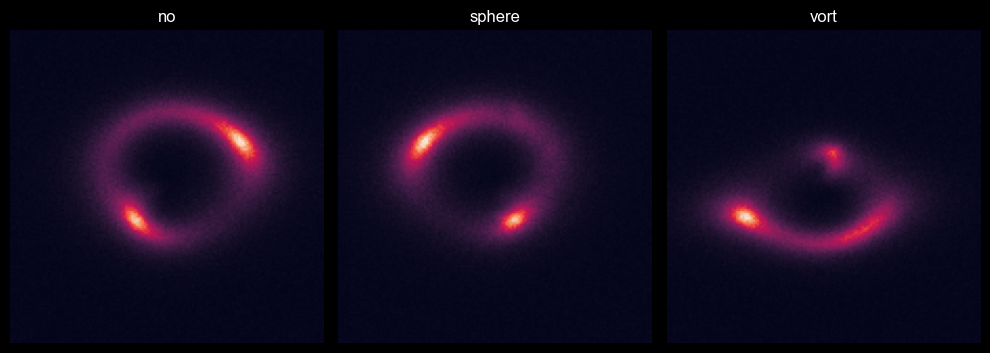

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))

for i, class_name in enumerate(classes):
    class_dir = os.path.join(train_dir, class_name)
    sample_file = os.listdir(class_dir)[0]
    img = np.load(os.path.join(class_dir, sample_file))

    axes[i].imshow(img[0]) #, cmap="gray")
    axes[i].set_title(class_name)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [4]:
class DatasetMultiClass(Dataset):
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        for class_name in classes:
            class_dir = os.path.join(root_dir, class_name)
            label = class_index[class_name]
            for file in os.listdir(class_dir):
                if file.endswith(".npy"):
                    self.samples.append((os.path.join(class_dir, file), label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = np.load(path).astype(np.float32)
        img = torch.from_numpy(img)

        if self.transform:
            img = self.transform(img)

        return img, label

In [5]:
# apply light augmentation as images are already normalized
train_transform = T.Compose([
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(degrees=30),
    T.Normalize(mean=[0.5], std=[0.5]), # normalize single channel with approx mean/std for lensing data
])

val_transform = T.Compose([
    T.Normalize(mean=[0.5], std=[0.5]),
])

train_dataset = DatasetMultiClass(train_dir, transform=train_transform)
val_dataset = DatasetMultiClass(val_dir,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset,   batch_size=32, shuffle=False)

print(f"Train : {len(train_dataset)}")
print(f"Val : {len(val_dataset)}")

Train : 30000
Val : 7500


I chose to use DenseNet121 pretrained on ImageNet as each layer receives feature maps from each preceding layer which is useful for a gravitational lensing classification task.

ResNet has other advantages but doesn't do multi-scale feature reuse.

In [6]:
def build_densenet(num_classes=3):
    """
    First conv layer adapted to preserve learned low-level features.
    Classifier head replaced for num_classes outputs.
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    old_conv = model.features.conv0
    new_conv = nn.Conv2d(in_channels=1, out_channels=old_conv.out_channels, kernel_size=old_conv.kernel_size, stride=old_conv.stride, padding=old_conv.padding, bias=False)
    # average pretrained weights across the 3 input channels
    new_conv.weight = nn.Parameter( old_conv.weight.mean(dim=1, keepdim=True))
    model.features.conv0 = new_conv

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, num_classes)
    )

    return model

model = build_densenet().to(device)

In [7]:
num_epochs = 20
lr = 1e-4
weight_decay = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

def run_epoch(loader, training=True):
    model.train() if training else model.eval()
    total_loss = 0.0
    correct = 0
    total = 0

    compute_grad = torch.enable_grad() if training else torch.no_grad()
    with compute_grad:
        for imgs, labels in tqdm(loader, leave=False):
            imgs, labels = imgs.to(device), labels.to(device)

            if training:
                optimizer.zero_grad()

            outputs = model(imgs)
            loss = criterion(outputs, labels)

            if training:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)

    return total_loss / total, correct / total


best_val_loss = float("inf")

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = run_epoch(train_loader, training=True)
    val_loss, val_acc = run_epoch(val_loader, training=False)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch}/{num_epochs} , "f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} , "f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_densenet.pth")

Epoch 1/20 , Train Loss: 0.9400  Acc: 0.5239 , Val Loss: 0.5201  Acc: 0.7901


Epoch 2/20 , Train Loss: 0.5124  Acc: 0.7897 , Val Loss: 0.3794  Acc: 0.8543


Epoch 3/20 , Train Loss: 0.4073  Acc: 0.8431 , Val Loss: 0.2928  Acc: 0.8901


Epoch 4/20 , Train Loss: 0.3548  Acc: 0.8651 , Val Loss: 0.3051  Acc: 0.8824


Epoch 5/20 , Train Loss: 0.3131  Acc: 0.8823 , Val Loss: 0.2949  Acc: 0.8903


...

Epoch 16/20 , Train Loss: 0.1377  Acc: 0.9517 , Val Loss: 0.1385  Acc: 0.9525


Epoch 17/20 , Train Loss: 0.1295  Acc: 0.9526 , Val Loss: 0.1345  Acc: 0.9545


Epoch 18/20 , Train Loss: 0.1214  Acc: 0.9564 , Val Loss: 0.1236  Acc: 0.9588


Epoch 19/20 , Train Loss: 0.1180  Acc: 0.9583 , Val Loss: 0.1232  Acc: 0.9577


Epoch 20/20 , Train Loss: 0.1168  Acc: 0.9584 , Val Loss: 0.1219  Acc: 0.9588


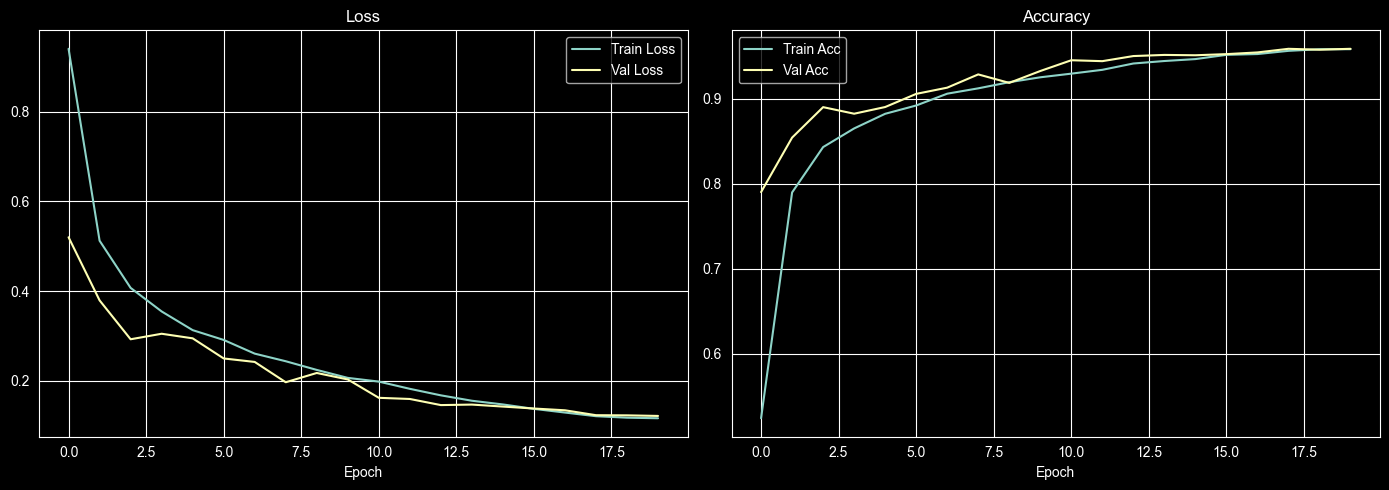

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"],   label="Val Acc")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

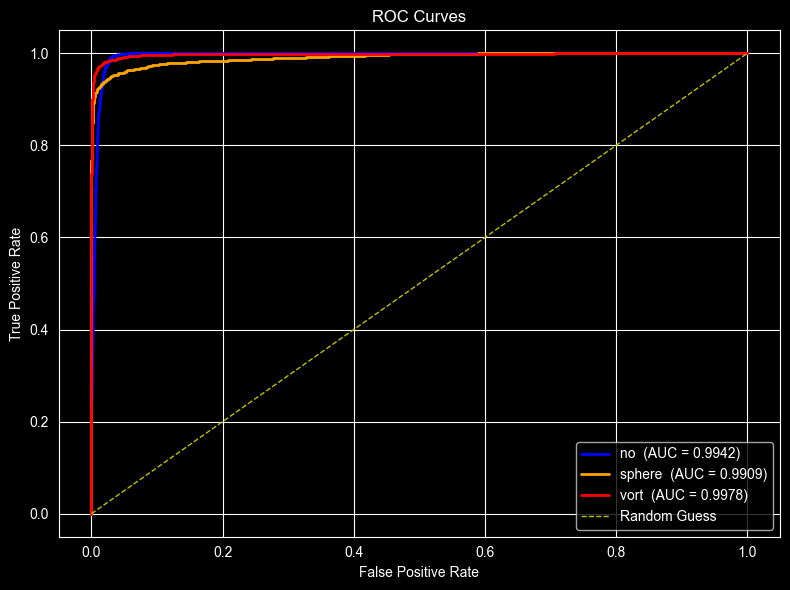

In [9]:
model.load_state_dict(torch.load("best_densenet.pth", map_location=device, weights_only=True))
model.eval()

all_labels = []
all_probs = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)   # (N, 3)
all_labels = np.concatenate(all_labels, axis=0)   # (N,)

labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

plt.figure(figsize=(8, 6))
colors = ["blue", "orange", "red"]

for i, (cls_name, color) in enumerate(zip(classes, colors)):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls_name}  (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], "y--", lw=1, label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves")
plt.legend()
plt.tight_layout()
plt.show()

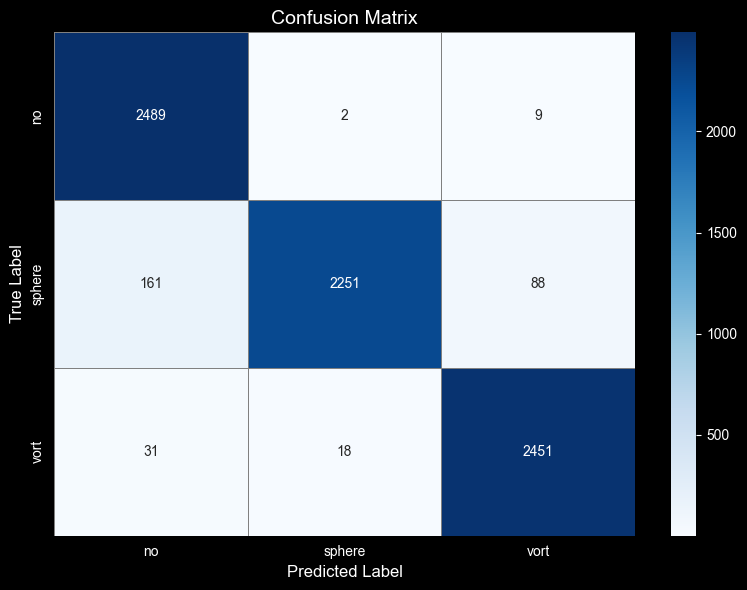

In [11]:
preds = np.argmax(all_probs, axis=1)
cm = confusion_matrix(all_labels, preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, linewidths=0.5, linecolor="gray")
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()